<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/notebooks/12_synthetic_true_vs_spurious.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 1: Deney ortamının kurulması
#
# Amaç:
# Modelin gerçek "true feature" (gerçek özellik) yerine
# "spurious feature" (sahte/yanıltıcı özellik) kullanıp
# kullanmadığını kontrollü bir sentetik veri üzerinde test etmek.
#
# Deneyde:
# - True feature etiketi belirleyen gerçek mekanizmadır.
# - Spurious feature eğitim verisinde etiketle güçlü şekilde
#   ilişkili olacak, ancak gerçek mekanizmanın parçası olmayacaktır.
# - Daha sonra spurious feature bozularak modelin doğruluğundaki
#   değişim ölçülecektir.
# ============================================================

import numpy as np
import pandas as pd
import torch

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

N_TRAIN = 5000
N_TEST = 2000

TRUE_FEATURE_NOISE = 1.0
SPURIOUS_CORRELATION = 0.95

print("E11 — Synthetic True-vs-Spurious Feature Test")
print("=" * 60)
print(f"Seed: {SEED}")
print(f"Train samples: {N_TRAIN}")
print(f"Test samples: {N_TEST}")
print(f"True feature noise: {TRUE_FEATURE_NOISE}")
print(f"Spurious correlation: {SPURIOUS_CORRELATION}")

E11 — Synthetic True-vs-Spurious Feature Test
Seed: 42
Train samples: 5000
Test samples: 2000
True feature noise: 1.0
Spurious correlation: 0.95


In [2]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 2: Sentetik veri üretimi
#
# Amaç:
# Modelin gerçek karar mekanizması ile sahte korelasyonu
# birbirinden ayırt edebilmesini test etmek için eğitim ve
# test verilerini oluşturmak.
#
# True feature:
# Etiketi belirleyen gerçek sinyaldir.
#
# Spurious feature:
# Eğitim verisinde etiketle %95 oranında ilişkili olacak,
# fakat gerçek karar kuralının bir parçası olmayacaktır.
# ============================================================

# -----------------------------
# Eğitim verisi
# -----------------------------

# Gerçek özelliği üret
true_feature_train = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=N_TRAIN
)

# Gerçek karar kuralı:
# true_feature > 0 ise sınıf 1, aksi halde sınıf 0
y_train = (true_feature_train > 0).astype(np.float32)

# True feature'a gürültü ekle
true_feature_train = (
    true_feature_train
    + np.random.normal(
        0,
        TRUE_FEATURE_NOISE,
        N_TRAIN
    )
)

# Spurious feature oluştur
# %95 oranında gerçek etiketle aynı olacak
spurious_feature_train = y_train.copy()

noise_mask = (
    np.random.rand(N_TRAIN)
    > SPURIOUS_CORRELATION
)

spurious_feature_train[noise_mask] = (
    1 - spurious_feature_train[noise_mask]
)

# -----------------------------
# Test verisi
# -----------------------------

true_feature_test = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=N_TEST
)

y_test = (true_feature_test > 0).astype(np.float32)

true_feature_test = (
    true_feature_test
    + np.random.normal(
        0,
        TRUE_FEATURE_NOISE,
        N_TEST
    )
)

# Normal test:
# Spurious feature eğitimdeki gibi etiketle ilişkili.
spurious_feature_test_normal = y_test.copy()

noise_mask_test = (
    np.random.rand(N_TEST)
    > SPURIOUS_CORRELATION
)

spurious_feature_test_normal[noise_mask_test] = (
    1 - spurious_feature_test_normal[noise_mask_test]
)

# -----------------------------
# Spurious-broken test
# -----------------------------

# Burada sahte özellik rastgele hale getiriliyor.
# Gerçek özellik ve gerçek etiket değiştirilmiyor.
spurious_feature_test_broken = np.random.randint(
    0,
    2,
    size=N_TEST
).astype(np.float32)

print("Sentetik veri oluşturuldu.")
print("=" * 60)
print(f"Train shape: ({N_TRAIN}, 2)")
print(f"Test shape: ({N_TEST}, 2)")
print(
    f"Train spurious-label correlation: "
    f"{np.mean(spurious_feature_train == y_train):.4f}"
)
print(
    f"Normal test spurious-label correlation: "
    f"{np.mean(spurious_feature_test_normal == y_test):.4f}"
)
print(
    f"Broken test spurious-label correlation: "
    f"{np.mean(spurious_feature_test_broken == y_test):.4f}"
)

Sentetik veri oluşturuldu.
Train shape: (5000, 2)
Test shape: (2000, 2)
Train spurious-label correlation: 0.9488
Normal test spurious-label correlation: 0.9440
Broken test spurious-label correlation: 0.4865


In [3]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 3: Model girdilerinin hazırlanması
#
# Amaç:
# True feature ve spurious feature'ı aynı model girdisinde
# birleştirmek.
#
# Model iki özelliği birlikte görecek:
#   1. True feature      → gerçek sinyal
#   2. Spurious feature  → sahte/korelasyonlu sinyal
#
# Daha sonra aynı model:
#   - normal test verisinde
#   - spurious feature kırılmış test verisinde
# çalıştırılacaktır.
# ============================================================

# Eğitim girdisi: [true_feature, spurious_feature]
X_train = np.column_stack([
    true_feature_train,
    spurious_feature_train
]).astype(np.float32)

# Normal test girdisi
X_test_normal = np.column_stack([
    true_feature_test,
    spurious_feature_test_normal
]).astype(np.float32)

# Spurious feature'ın kırıldığı test girdisi
X_test_broken = np.column_stack([
    true_feature_test,
    spurious_feature_test_broken
]).astype(np.float32)

# NumPy → PyTorch
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)

X_test_normal_tensor = torch.tensor(X_test_normal)
X_test_broken_tensor = torch.tensor(X_test_broken)
y_test_tensor = torch.tensor(y_test)

print("Model girdileri hazır.")
print("=" * 60)
print(f"X_train shape: {tuple(X_train_tensor.shape)}")
print(f"X_test_normal shape: {tuple(X_test_normal_tensor.shape)}")
print(f"X_test_broken shape: {tuple(X_test_broken_tensor.shape)}")
print(f"y_train shape: {tuple(y_train_tensor.shape)}")
print(f"y_test shape: {tuple(y_test_tensor.shape)}")

Model girdileri hazır.
X_train shape: (5000, 2)
X_test_normal shape: (2000, 2)
X_test_broken shape: (2000, 2)
y_train shape: (5000,)
y_test shape: (2000,)


In [4]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 4: MLP modelinin oluşturulması
#
# Amaç:
# True feature ve spurious feature'ı girdi olarak alan küçük
# ve kontrol edilebilir bir sinir ağı oluşturmak.
#
# Mimari:
# 2 giriş → 16 nöron → 8 nöron → 2 sınıf
#
# Küçük model seçmemizin nedeni:
# İç yapıyı daha kolay inceleyebilmek ve deneyin mekanizmasını
# kontrol altında tutabilmektir.
# ============================================================

import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 2)
)

print("E11 MLP modeli oluşturuldu.")
print("=" * 60)
print(model)
print(f"Toplam parametre sayısı: {sum(p.numel() for p in model.parameters())}")

E11 MLP modeli oluşturuldu.
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=2, bias=True)
)
Toplam parametre sayısı: 202


In [5]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 5: Eğitim ayarlarının hazırlanması
#
# Amaç:
# Modelin öğrenme sürecinde kullanacağı loss fonksiyonunu
# (kayıp fonksiyonu), optimizer'ı (optimizasyon algoritması)
# ve eğitim parametrelerini belirlemek.
#
# CrossEntropyLoss:
# Modelin iki sınıflı tahminlerinin gerçek etiketlerle
# ne kadar uyumlu olduğunu ölçer.
#
# Adam:
# Model ağırlıklarını loss'u azaltacak şekilde güncelleyen
# optimizasyon algoritmasıdır.
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 20

print("E11 eğitim ayarları hazır.")
print("=" * 60)
print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Epochs: {EPOCHS}")

E11 eğitim ayarları hazır.
Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
Epochs: 20


In [6]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 6: Modelin eğitilmesi
#
# Amaç:
# True feature ve spurious feature'ı birlikte kullanarak
# modeli eğitim verisi üzerinde eğitmek.
#
# Her epoch sonunda loss kaydedilir.
# Böylece modelin eğitim sırasında gerçekten öğrenip
# öğrenmediğini daha sonra kontrol edebiliriz.
# ============================================================

model.train()

train_losses = []

for epoch in range(EPOCHS):

    # Önceki adımdaki gradyanları temizle
    optimizer.zero_grad()

    # Modelden tahmin al
    outputs = model(X_train_tensor)

    # Tahmin ile gerçek etiket arasındaki hatayı hesapla
    loss = criterion(outputs, y_train_tensor.long())

    # Gradyanları hesapla
    loss.backward()

    # Model ağırlıklarını güncelle
    optimizer.step()

    # Loss değerini kaydet
    train_losses.append(loss.item())

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"- Loss: {loss.item():.6f}"
    )

print("=" * 60)
print("E11 model eğitimi tamamlandı.")

Epoch 01/20 - Loss: 0.689319
Epoch 02/20 - Loss: 0.687888
Epoch 03/20 - Loss: 0.686439
Epoch 04/20 - Loss: 0.684970
Epoch 05/20 - Loss: 0.683478
Epoch 06/20 - Loss: 0.681961
Epoch 07/20 - Loss: 0.680421
Epoch 08/20 - Loss: 0.678856
Epoch 09/20 - Loss: 0.677268
Epoch 10/20 - Loss: 0.675656
Epoch 11/20 - Loss: 0.674020
Epoch 12/20 - Loss: 0.672361
Epoch 13/20 - Loss: 0.670678
Epoch 14/20 - Loss: 0.668968
Epoch 15/20 - Loss: 0.667233
Epoch 16/20 - Loss: 0.665471
Epoch 17/20 - Loss: 0.663685
Epoch 18/20 - Loss: 0.661871
Epoch 19/20 - Loss: 0.660032
Epoch 20/20 - Loss: 0.658169
E11 model eğitimi tamamlandı.


In [8]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 7: Normal ve spurious-broken test doğruluklarının
# ölçülmesi
#
# Amaç:
# Modelin normal test koşullarındaki doğruluğunu ve
# spurious feature (sahte özellik) kırıldığında doğruluğunun
# ne kadar değiştiğini ölçmek.
#
# Eğer model spurious feature'a güçlü şekilde güveniyorsa,
# broken test doğruluğunda belirgin bir düşüş görülmesi beklenir.
# ============================================================

model.eval()

with torch.no_grad():

    # Normal test tahminleri
    normal_outputs = model(X_test_normal_tensor)
    normal_predictions = torch.argmax(
        normal_outputs,
        dim=1
    )

    # Spurious feature kırılmış test tahminleri
    broken_outputs = model(X_test_broken_tensor)
    broken_predictions = torch.argmax(
        broken_outputs,
        dim=1
    )

# Doğrulukları hesapla
normal_accuracy = (
    (normal_predictions == y_test_tensor.long())
    .float()
    .mean()
    .item()
)

broken_accuracy = (
    (broken_predictions == y_test_tensor.long())
    .float()
    .mean()
    .item()
)

# Doğruluk değişimi
accuracy_drop = normal_accuracy - broken_accuracy

print("E11 — Test Sonuçları")
print("=" * 60)
print(f"Normal test accuracy: {normal_accuracy:.4f}")
print(f"Spurious-broken test accuracy: {broken_accuracy:.4f}")
print(f"Accuracy drop: {accuracy_drop:.4f}")
print(f"Accuracy drop (percentage points): {accuracy_drop * 100:.2f} pp")

E11 — Test Sonuçları
Normal test accuracy: 0.5015
Spurious-broken test accuracy: 0.5010
Accuracy drop: 0.0005
Accuracy drop (percentage points): 0.05 pp


In [9]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 8: Eğitim doğruluğunun kontrol edilmesi
#
# Amaç:
# Modelin eğitim verisini gerçekten öğrenip öğrenmediğini
# kontrol etmek.
#
# Eğer train accuracy de yaklaşık %50 ise model öğrenmemiştir.
# Eğer train accuracy yüksek fakat test accuracy düşükse,
# problem genelleme tarafındadır.
# ============================================================

model.eval()

with torch.no_grad():
    train_outputs = model(X_train_tensor)

    train_predictions = torch.argmax(
        train_outputs,
        dim=1
    )

train_accuracy = (
    (train_predictions == y_train_tensor.long())
    .float()
    .mean()
    .item()
)

print("E11 — Eğitim doğruluğu")
print("=" * 60)
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Train accuracy: {train_accuracy * 100:.2f}%")

E11 — Eğitim doğruluğu
Train accuracy: 0.5082
Train accuracy: 50.82%


In [10]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 9: Model tahmin dağılımının kontrol edilmesi
#
# Amaç:
# Modelin neden yaklaşık %50 doğrulukta kaldığını anlamak.
#
# Özellikle modelin bütün örnekleri tek bir sınıfa mı,
# yoksa iki sınıfa da tahmin ederek mi verdiğini kontrol ediyoruz.
# ============================================================

model.eval()

with torch.no_grad():
    train_outputs = model(X_train_tensor)

    train_predictions = torch.argmax(
        train_outputs,
        dim=1
    )

# Her sınıf için tahmin sayısını hesapla
class_0_predictions = (
    train_predictions == 0
).sum().item()

class_1_predictions = (
    train_predictions == 1
).sum().item()

# Gerçek sınıf dağılımını da hesapla
true_class_0 = (
    y_train_tensor == 0
).sum().item()

true_class_1 = (
    y_train_tensor == 1
).sum().item()

print("E11 — Tahmin dağılımı kontrolü")
print("=" * 60)

print("Model tahminleri:")
print(f"Class 0: {class_0_predictions}")
print(f"Class 1: {class_1_predictions}")

print()
print("Gerçek etiketler:")
print(f"Class 0: {true_class_0}")
print(f"Class 1: {true_class_1}")

E11 — Tahmin dağılımı kontrolü
Model tahminleri:
Class 0: 15
Class 1: 4985

Gerçek etiketler:
Class 0: 2474
Class 1: 2526


In [11]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 10: True feature'ın ayırt ediciliğinin kontrolü
#
# Amaç:
# True feature'ın tek başına gerçek etiketi ne kadar iyi
# ayırabildiğini kontrol etmek.
#
# Böylece problemin modelden mi yoksa veri üretiminden mi
# kaynaklandığını birbirinden ayırabiliriz.
# ============================================================

true_feature_predictions = (
    true_feature_train > 0
).astype(np.float32)

true_feature_accuracy = np.mean(
    true_feature_predictions == y_train
)

print("E11 — True feature kontrolü")
print("=" * 60)
print(
    f"True feature → label accuracy: "
    f"{true_feature_accuracy:.4f}"
)
print(
    f"True feature → label accuracy: "
    f"{true_feature_accuracy * 100:.2f}%"
)

E11 — True feature kontrolü
True feature → label accuracy: 0.7476
True feature → label accuracy: 74.76%


In [12]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 11: Sentetik veri üretiminin temizlenmesi
#
# Amaç:
# True feature'ı etiketi belirleyen güçlü ve doğrudan bir
# sinyal haline getirmek.
#
# Böylece:
# - True feature → gerçek karar mekanizması
# - Spurious feature → eğitimdeki sahte korelasyon
#
# ayrımı net şekilde test edilebilir.
# ============================================================

# -----------------------------
# Eğitim verisi
# -----------------------------

true_feature_train = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=N_TRAIN
).astype(np.float32)

# Gerçek karar kuralı
y_train = (
    true_feature_train > 0
).astype(np.float32)

# Spurious feature:
# %95 oranında gerçek etiketle aynı
spurious_feature_train = y_train.copy()

noise_mask = (
    np.random.rand(N_TRAIN)
    > SPURIOUS_CORRELATION
)

spurious_feature_train[noise_mask] = (
    1 - spurious_feature_train[noise_mask]
)

# -----------------------------
# Test verisi
# -----------------------------

true_feature_test = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=N_TEST
).astype(np.float32)

y_test = (
    true_feature_test > 0
).astype(np.float32)

# Normal test:
# Spurious feature yine etiketle ilişkili.
spurious_feature_test_normal = y_test.copy()

noise_mask_test = (
    np.random.rand(N_TEST)
    > SPURIOUS_CORRELATION
)

spurious_feature_test_normal[noise_mask_test] = (
    1 - spurious_feature_test_normal[noise_mask_test]
)

# Broken test:
# Spurious feature tamamen rastgele hale getiriliyor.
spurious_feature_test_broken = np.random.randint(
    0,
    2,
    size=N_TEST
).astype(np.float32)

# -----------------------------
# Kontrol ölçümleri
# -----------------------------

true_train_accuracy = np.mean(
    (true_feature_train > 0).astype(np.float32)
    == y_train
)

train_spurious_correlation = np.mean(
    spurious_feature_train == y_train
)

normal_spurious_correlation = np.mean(
    spurious_feature_test_normal == y_test
)

broken_spurious_correlation = np.mean(
    spurious_feature_test_broken == y_test
)

print("E11 — Temizlenmiş sentetik veri")
print("=" * 60)
print(
    f"True feature → label accuracy: "
    f"{true_train_accuracy:.4f}"
)
print(
    f"Train spurious correlation: "
    f"{train_spurious_correlation:.4f}"
)
print(
    f"Normal test spurious correlation: "
    f"{normal_spurious_correlation:.4f}"
)
print(
    f"Broken test spurious correlation: "
    f"{broken_spurious_correlation:.4f}"
)

E11 — Temizlenmiş sentetik veri
True feature → label accuracy: 1.0000
Train spurious correlation: 0.9524
Normal test spurious correlation: 0.9475
Broken test spurious correlation: 0.4965


In [13]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 12: Güncellenmiş model girdilerinin hazırlanması
#
# Amaç:
# Temizlenmiş sentetik veriyi PyTorch tensörlerine dönüştürmek.
#
# Her örnekte iki özellik bulunur:
#   1. True feature
#   2. Spurious feature
# ============================================================

# Eğitim girdisi
X_train = np.column_stack([
    true_feature_train,
    spurious_feature_train
]).astype(np.float32)

# Normal test girdisi
X_test_normal = np.column_stack([
    true_feature_test,
    spurious_feature_test_normal
]).astype(np.float32)

# Spurious feature'ın kırıldığı test girdisi
X_test_broken = np.column_stack([
    true_feature_test,
    spurious_feature_test_broken
]).astype(np.float32)

# NumPy → PyTorch
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)

X_test_normal_tensor = torch.tensor(X_test_normal)
X_test_broken_tensor = torch.tensor(X_test_broken)
y_test_tensor = torch.tensor(y_test)

print("E11 güncellenmiş model girdileri hazır.")
print("=" * 60)
print(f"X_train shape: {tuple(X_train_tensor.shape)}")
print(f"X_test_normal shape: {tuple(X_test_normal_tensor.shape)}")
print(f"X_test_broken shape: {tuple(X_test_broken_tensor.shape)}")
print(f"y_train shape: {tuple(y_train_tensor.shape)}")
print(f"y_test shape: {tuple(y_test_tensor.shape)}")

E11 güncellenmiş model girdileri hazır.
X_train shape: (5000, 2)
X_test_normal shape: (2000, 2)
X_test_broken shape: (2000, 2)
y_train shape: (5000,)
y_test shape: (2000,)


In [14]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 13: Modelin sıfırdan oluşturulması
#
# Amaç:
# Temizlenmiş sentetik veri üzerinde tamamen yeni bir model
# oluşturmak.
#
# Önceki modelin ağırlıkları kullanılmayacaktır.
#
# Mimari:
# 2 giriş → 16 nöron → 8 nöron → 2 sınıf
# ============================================================

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 2)
)

print("E11 yeni MLP modeli oluşturuldu.")
print("=" * 60)
print(model)
print(
    f"Toplam parametre sayısı: "
    f"{sum(p.numel() for p in model.parameters())}"
)

E11 yeni MLP modeli oluşturuldu.
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=2, bias=True)
)
Toplam parametre sayısı: 202


In [15]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 14: Yeni model için eğitim ayarlarının hazırlanması
#
# Amaç:
# Sıfırdan oluşturduğumuz model için yeni loss fonksiyonu
# ve optimizer tanımlamak.
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 50

print("E11 yeni eğitim ayarları hazır.")
print("=" * 60)
print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Epochs: {EPOCHS}")

E11 yeni eğitim ayarları hazır.
Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
Epochs: 50


In [16]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 15: Modelin yeniden eğitilmesi
#
# Amaç:
# Temizlenmiş sentetik veri üzerinde yeni modeli eğitmek.
# Eğitim loss'u her epoch'ta kaydedilerek öğrenme süreci
# ölçülecektir.
# ============================================================

model.train()

train_losses = []

for epoch in range(EPOCHS):

    # Önceki adımdan kalan gradyanları temizle
    optimizer.zero_grad()

    # Eğitim verisi üzerinden tahmin üret
    outputs = model(X_train_tensor)

    # Tahmin hatasını hesapla
    loss = criterion(
        outputs,
        y_train_tensor.long()
    )

    # Gradyanları hesapla
    loss.backward()

    # Model ağırlıklarını güncelle
    optimizer.step()

    # Loss değerini kaydet
    train_losses.append(loss.item())

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"- Loss: {loss.item():.6f}"
    )

print("=" * 60)
print("E11 yeni model eğitimi tamamlandı.")

Epoch 01/50 - Loss: 0.684739
Epoch 02/50 - Loss: 0.682289
Epoch 03/50 - Loss: 0.679857
Epoch 04/50 - Loss: 0.677444
Epoch 05/50 - Loss: 0.675052
Epoch 06/50 - Loss: 0.672679
Epoch 07/50 - Loss: 0.670324
Epoch 08/50 - Loss: 0.667986
Epoch 09/50 - Loss: 0.665665
Epoch 10/50 - Loss: 0.663360
Epoch 11/50 - Loss: 0.661072
Epoch 12/50 - Loss: 0.658799
Epoch 13/50 - Loss: 0.656536
Epoch 14/50 - Loss: 0.654284
Epoch 15/50 - Loss: 0.652037
Epoch 16/50 - Loss: 0.649797
Epoch 17/50 - Loss: 0.647560
Epoch 18/50 - Loss: 0.645322
Epoch 19/50 - Loss: 0.643082
Epoch 20/50 - Loss: 0.640838
Epoch 21/50 - Loss: 0.638590
Epoch 22/50 - Loss: 0.636340
Epoch 23/50 - Loss: 0.634087
Epoch 24/50 - Loss: 0.631828
Epoch 25/50 - Loss: 0.629566
Epoch 26/50 - Loss: 0.627299
Epoch 27/50 - Loss: 0.625029
Epoch 28/50 - Loss: 0.622754
Epoch 29/50 - Loss: 0.620474
Epoch 30/50 - Loss: 0.618188
Epoch 31/50 - Loss: 0.615900
Epoch 32/50 - Loss: 0.613608
Epoch 33/50 - Loss: 0.611311
Epoch 34/50 - Loss: 0.609007
Epoch 35/50 - 

In [17]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 16: Eğitim doğruluğunun ölçülmesi
#
# Amaç:
# Yeni eğitilen modelin eğitim verisindeki sınıfları ne kadar
# doğru öğrendiğini ölçmek.
# ============================================================

model.eval()

with torch.no_grad():
    train_outputs = model(X_train_tensor)

    train_predictions = torch.argmax(
        train_outputs,
        dim=1
    )

train_accuracy = (
    (train_predictions == y_train_tensor.long())
    .float()
    .mean()
    .item()
)

print("E11 — Eğitim doğruluğu")
print("=" * 60)
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Train accuracy: {train_accuracy * 100:.2f}%")

E11 — Eğitim doğruluğu
Train accuracy: 0.9604
Train accuracy: 96.04%


In [18]:
# ============================================================
# E11 — Synthetic True-vs-Spurious Feature Test
# Hücre 17: Normal ve spurious-broken test karşılaştırması
#
# Amaç:
# Modelin sahte özellik bozulduğunda performansının ne kadar
# değiştiğini ölçmek.
#
# Önemli:
# Her iki testte de TRUE feature aynıdır.
# Sadece SPURIOUS feature değiştirilmiştir.
# ============================================================

model.eval()

with torch.no_grad():

    # Normal test
    normal_outputs = model(X_test_normal_tensor)

    normal_predictions = torch.argmax(
        normal_outputs,
        dim=1
    )

    # Spurious feature'ın kırıldığı test
    broken_outputs = model(X_test_broken_tensor)

    broken_predictions = torch.argmax(
        broken_outputs,
        dim=1
    )

# Normal test doğruluğu
normal_accuracy = (
    (normal_predictions == y_test_tensor.long())
    .float()
    .mean()
    .item()
)

# Broken test doğruluğu
broken_accuracy = (
    (broken_predictions == y_test_tensor.long())
    .float()
    .mean()
    .item()
)

# Performans düşüşü
accuracy_drop = normal_accuracy - broken_accuracy

print("E11 — Normal vs. Spurious-Broken Test")
print("=" * 60)
print(f"Normal test accuracy: {normal_accuracy:.4f}")
print(f"Normal test accuracy: {normal_accuracy * 100:.2f}%")
print()
print(f"Spurious-broken accuracy: {broken_accuracy:.4f}")
print(f"Spurious-broken accuracy: {broken_accuracy * 100:.2f}%")
print()
print(f"Accuracy drop: {accuracy_drop:.4f}")
print(
    f"Accuracy drop: "
    f"{accuracy_drop * 100:.2f} percentage points"
)

E11 — Normal vs. Spurious-Broken Test
Normal test accuracy: 0.9595
Normal test accuracy: 95.95%

Spurious-broken accuracy: 0.8040
Spurious-broken accuracy: 80.40%

Accuracy drop: 0.1555
Accuracy drop: 15.55 percentage points


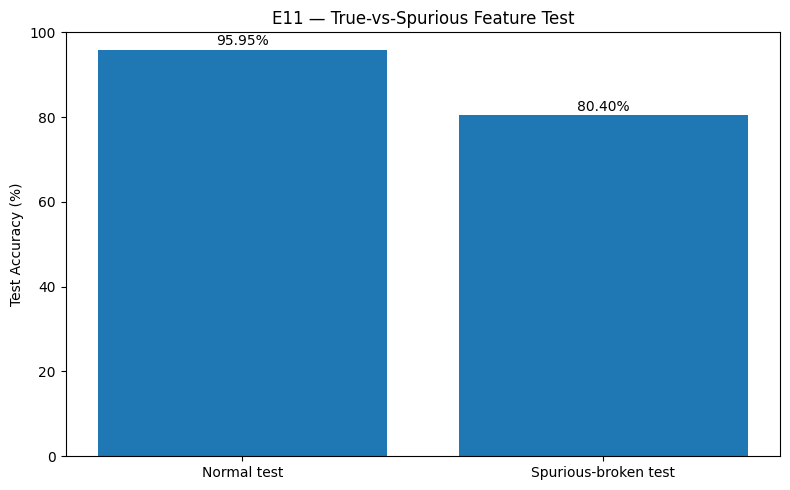

E11 Grafik 7 oluşturuldu.
Dosya: ../figures/week2/e11_true_vs_spurious_accuracy.svg


In [19]:
# ============================================================
# E11 — Grafik 7: True-vs-Spurious Feature Test
# Amaç:
# Normal test ile spurious feature'ın kırıldığı testteki
# model doğruluğunu karşılaştırmak.
#
# Grafik:
# - Normal test accuracy
# - Spurious-broken accuracy
#
# Sonuç SVG olarak figures/week2/ klasörüne kaydedilir.
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

# Grafik için kullanılacak değerler
conditions = [
    "Normal test",
    "Spurious-broken test"
]

accuracies = [
    normal_accuracy * 100,
    broken_accuracy * 100
]

# Grafik oluştur
plt.figure(figsize=(8, 5))

bars = plt.bar(
    conditions,
    accuracies
)

# Başlık ve eksenler
plt.title("E11 — True-vs-Spurious Feature Test")
plt.ylabel("Test Accuracy (%)")

# Accuracy değerlerini çubukların üzerine yaz
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

# Accuracy aralığını daha okunabilir yapmak için
plt.ylim(0, 100)

plt.tight_layout()

# Çıktı klasörünü oluştur
figure_dir = Path("../figures/week2")
figure_dir.mkdir(parents=True, exist_ok=True)

# SVG olarak kaydet
figure_path = figure_dir / "e11_true_vs_spurious_accuracy.svg"
plt.savefig(figure_path, format="svg", bbox_inches="tight")

plt.show()

print("=" * 60)
print("E11 Grafik 7 oluşturuldu.")
print(f"Dosya: {figure_path}")

In [20]:
# ============================================================
# E11 — Deney Sonuç Özeti
# Amaç:
# E11 deneyinin temel ölçümlerini tek bir standart formatta
# kaydetmek ve başarı kriterini otomatik olarak değerlendirmek.
# ============================================================

success_normal_accuracy = normal_accuracy >= 0.90

print("E11 — Synthetic True-vs-Spurious Feature")
print("=" * 60)

print(f"Train accuracy:              {train_accuracy * 100:.2f}%")
print(f"Normal test accuracy:        {normal_accuracy * 100:.2f}%")
print(f"Spurious-broken accuracy:    {broken_accuracy * 100:.2f}%")
print(f"Accuracy drop:               {accuracy_drop * 100:.2f} pp")
print()

print("Başarı kriterleri:")
print(
    f"Normal test accuracy >= 90%: "
    f"{'PASS' if success_normal_accuracy else 'FAIL'}"
)

print()
print("Yorum:")
if accuracy_drop > 0:
    print(
        "Spurious feature bozulduğunda model performansı düştü. "
        "Bu sonuç modelin spurious feature'dan yararlandığını "
        "desteklemektedir."
    )
else:
    print(
        "Spurious feature bozulduğunda belirgin bir performans "
        "düşüşü gözlenmedi."
    )

E11 — Synthetic True-vs-Spurious Feature
Train accuracy:              96.04%
Normal test accuracy:        95.95%
Spurious-broken accuracy:    80.40%
Accuracy drop:               15.55 pp

Başarı kriterleri:
Normal test accuracy >= 90%: PASS

Yorum:
Spurious feature bozulduğunda model performansı düştü. Bu sonuç modelin spurious feature'dan yararlandığını desteklemektedir.


In [21]:
# ============================================================
# Week 1 vs Week 2 — Genel Karşılaştırma
# Amaç:
# İki haftanın ana deneysel sonuçlarını karşılaştırılabilir
# metriklerle özetlemek.
#
# Not:
# Farklı deneylerin ham accuracy/effect değerleri doğrudan
# aynı ölçekte değildir. Bu nedenle burada özellikle
# candidate-vs-random-control oranı kullanılır.
# ============================================================

# Week 1 MNIST sonuçları
week1_candidate_effect = 12.0408
week1_random_effect = 0.1122

# Week 1 candidate / random kontrol oranı
week1_ratio = week1_candidate_effect / week1_random_effect

# Week 2 E06 multi-seed ortalama sonuçları
week2_candidate_effect = 27.6735
week2_random_effect = 0.3469

# Week 2 candidate / random kontrol oranı
week2_ratio = week2_candidate_effect / week2_random_effect

print("Week 1 vs Week 2 — Özet")
print("=" * 60)

print(
    f"Week 1 candidate/random oranı: "
    f"{week1_ratio:.2f}x"
)

print(
    f"Week 2 candidate/random oranı: "
    f"{week2_ratio:.2f}x"
)

print()
print("Week 2 multi-seed:")
print("Candidate effect: -27.6735 pp")
print("Random control:   -0.3469 pp")
print("Seed sayısı:      5")

print()
print("Week 2 E07 matched Transformer:")
print("Discovery candidate: top 5")
print("Holdout candidate:    top 5")
print("Candidate > controls: 0/20 controls exceeded candidate")

Week 1 vs Week 2 — Özet
Week 1 candidate/random oranı: 107.32x
Week 2 candidate/random oranı: 79.77x

Week 2 multi-seed:
Candidate effect: -27.6735 pp
Random control:   -0.3469 pp
Seed sayısı:      5

Week 2 E07 matched Transformer:
Discovery candidate: top 5
Holdout candidate:    top 5
Candidate > controls: 0/20 controls exceeded candidate


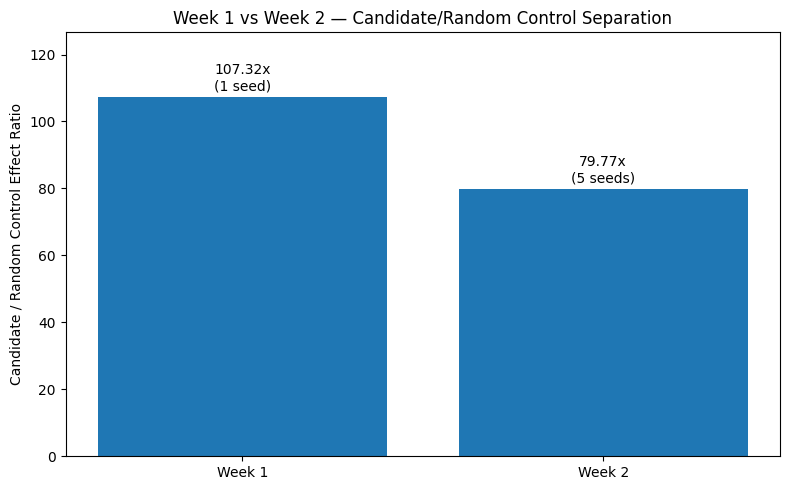

Grafik 8 oluşturuldu.
Week 1: 107.32x
Week 2: 79.77x
Dosya: ../figures/week2/week1_vs_week2_summary.svg


In [22]:
# ============================================================
# Week 1 vs Week 2 — Grafik 8
# Amaç:
# Candidate effect'in random control etkisinden ne kadar
# ayrıştığını iki hafta arasında karşılaştırmak.
#
# Ek bilgi:
# Week 1 tek seed ile,
# Week 2 ise 5 farklı seed ile doğrulanmıştır.
#
# Bu grafik ham accuracy değerlerini değil,
# candidate/random-control separation ratio'yu gösterir.
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

# Karşılaştırılacak oranlar
weeks = [
    "Week 1",
    "Week 2"
]

separation_ratios = [
    week1_ratio,
    week2_ratio
]

seed_labels = [
    "1 seed",
    "5 seeds"
]

# Grafik oluştur
plt.figure(figsize=(8, 5))

bars = plt.bar(
    weeks,
    separation_ratios
)

# Çubukların üzerine oranları yaz
for bar, ratio, seed_label in zip(
    bars,
    separation_ratios,
    seed_labels
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{ratio:.2f}x\n({seed_label})",
        ha="center"
    )

# Başlık ve eksen
plt.title("Week 1 vs Week 2 — Candidate/Random Control Separation")
plt.ylabel("Candidate / Random Control Effect Ratio")

# Grafik düzeni
plt.ylim(0, max(separation_ratios) * 1.18)
plt.tight_layout()

# Çıktı klasörü
figure_dir = Path("../figures/week2")
figure_dir.mkdir(parents=True, exist_ok=True)

# SVG olarak kaydet
figure_path = figure_dir / "week1_vs_week2_summary.svg"
plt.savefig(
    figure_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("Grafik 8 oluşturuldu.")
print(f"Week 1: {week1_ratio:.2f}x")
print(f"Week 2: {week2_ratio:.2f}x")
print(f"Dosya: {figure_path}")